# Imports

In [ ]:
import pandas as pd

# Read the data with  BVI and social vulnerability indicators

In [6]:
root = "/mnt/e/SOCIAL_PAPER/"

bvi_social_data = pd.read_csv(f"{root}PFA_results/bivariate_bins.csv")

bvi_social_data = bvi_social_data[["County Name", 'Bridge Vulnerability Index (BVI)', 'rank', 'final_scores_bin', 'SVI_bin', 'combined', 'Economic pressure']]

In [7]:
bvi_social_data.head()

,County Name,Bridge Vulnerability Index (BVI),rank,final_scores_bin,SVI_bin,combined,Economic pressure
0,Alameda,0.295701,39,1,A,A1,0.003534
1,Alpine,0.242499,45,1,A,A1,0.023459
2,Amador,0.802804,3,3,A,A3,0.012039
3,Butte,0.573848,14,2,B,B2,0.005397
4,Calaveras,0.416861,27,2,A,A2,0.005231


# Get the % of poor bridges corrected by the deck size 

In [ ]:
# Read county-level data
county_data = pd.read_excel(
    "/mnt/e/SOCIAL_PAPER/California_county_GDP_2023/California_GDP_manually_extracted.xlsx",
)

# Multiply the GDP by 1000 to convert it to dollars
county_data["GDP2023"] = county_data["GDP2023"] * 1000


In [16]:

# Merge the on the county name
merged_df = pd.merge(
    bvi_social_data, county_data, left_on="County Name", right_on="County"
)

merged_df.drop(columns=["County"], inplace=True)	

merged_df["Poor bridges replacement cost"] = merged_df["Economic pressure"] * merged_df["GDP2023"]

In [25]:
# Add rank based on the poor bridges replacement cost
merged_df["Poor bridges replacement cost rank"] = merged_df["Poor bridges replacement cost"].rank(ascending=False)

merged_df.sort_values("rank", inplace=True)

merged_df.head()

,County Name,Bridge Vulnerability Index (BVI),rank,final_scores_bin,SVI_bin,combined,Economic pressure,GDP2023,Poor bridges replacement cost,Poor bridges replacement cost rank
7,Del Norte,1.000000,1,3,B,B3,0.008698,844062000,7.341241e+06,49.0
54,Tuolumne,0.875934,2,3,B,B3,0.014544,2610180000,3.796201e+07,38.0
2,Amador,0.802804,3,3,A,A3,0.012039,1659330000,1.997672e+07,43.0
46,Siskiyou,0.739980,4,3,B,B3,0.012491,1849450000,2.310095e+07,42.0
28,Nevada,0.736774,5,3,A,A3,0.010666,4747160000,5.063172e+07,36.0


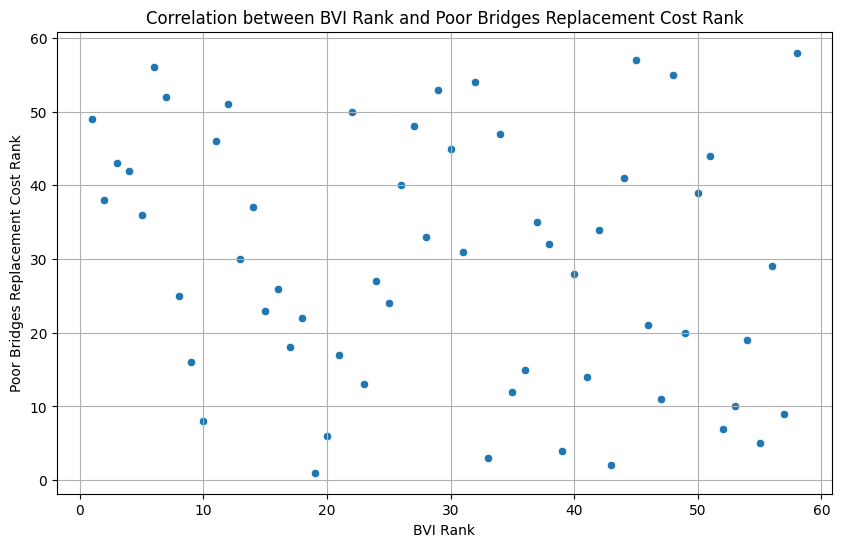

In [26]:
# Plot the correlation between BVI rank and Poor bridges replacement cost rank
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=merged_df,
    x="rank",
    y="Poor bridges replacement cost rank",
)
plt.title("Correlation between BVI Rank and Poor Bridges Replacement Cost Rank")
plt.xlabel("BVI Rank")
plt.ylabel("Poor Bridges Replacement Cost Rank")
plt.grid(True)
plt.show()

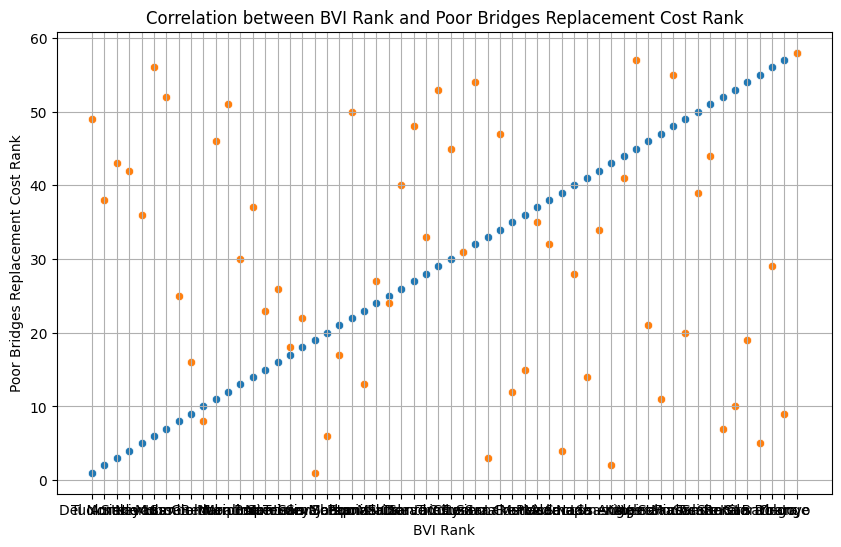

In [27]:
# Plot the correlation between BVI rank and Poor bridges replacement cost rank
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=merged_df,
    x="County Name",
    y="rank",	
)
sns.scatterplot(
    data=merged_df,
    x="County Name",
    y="Poor bridges replacement cost rank",
)
plt.title("Correlation between BVI Rank and Poor Bridges Replacement Cost Rank")
plt.xlabel("BVI Rank")
plt.ylabel("Poor Bridges Replacement Cost Rank")
plt.grid(True)
plt.show()

In [28]:
# Add a column in merged_df that shows the change in rank between BVI rank and Poor bridges replacement cost rank
merged_df["Rank Change"] = merged_df["rank"] - merged_df["Poor bridges replacement cost rank"]
merged_df.head()

,County Name,Bridge Vulnerability Index (BVI),rank,final_scores_bin,SVI_bin,combined,Economic pressure,GDP2023,Poor bridges replacement cost,Poor bridges replacement cost rank,Rank Change
7,Del Norte,1.000000,1,3,B,B3,0.008698,844062000,7.341241e+06,49.0,-48.0
54,Tuolumne,0.875934,2,3,B,B3,0.014544,2610180000,3.796201e+07,38.0,-36.0
2,Amador,0.802804,3,3,A,A3,0.012039,1659330000,1.997672e+07,43.0,-40.0
46,Siskiyou,0.739980,4,3,B,B3,0.012491,1849450000,2.310095e+07,42.0,-38.0
28,Nevada,0.736774,5,3,A,A3,0.010666,4747160000,5.063172e+07,36.0,-31.0


In [29]:
merged_df.to_csv(f"{root}PFA_results/bvi_poorbrdgs_benchmarking.csv", index=False)